In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve

In [2]:
#from google.colab import drive
#drive.mount('/content/drive')

In [3]:
os.listdir()

['.ipynb_checkpoints',
 'cartera_variable_respuesta_candidato.csv',
 'dataset_candidato.csv',
 'generacion_y.ipynb',
 'Prueba_Correo_Instrucciones_DS_Risk_Analytics.docx',
 'respuesta.csv',
 'Revision variables.ipynb']

In [4]:
#ruta=r"/content/drive/MyDrive/Nequi/"

In [5]:
### variables disponibles al momento de la solicitud/originación
predictoras=pd.read_csv("dataset_candidato.csv",engine='c',sep=';')
predictoras

,application_id,application_date,age,sexo,monthly_income_declared,app_tenure_months,avg_monthly_topups,num_transactions_last_90d,pct_p2p_transfers,device_price_tier,has_bureau_record,bureau_score,utility_payment_ontime_rate,telco_payment_ontime_rate,digital_engagement_score,monto_bono_referidos,requested_amount,product_type,disbursed_flag
0,CAND-02052,1/01/24,22,M,1149897.0,7,14838.0,2,0.712,3,False,NaN,0.524,0.728,52.7,0.0,1160359.0,compra_cartera,True
1,CAND-00752,1/01/24,33,M,616023.0,11,51171.0,3,0.288,3,False,NaN,0.822,0.938,50.3,0.0,273514.0,libre_inversion,True
2,CAND-00542,1/01/24,43,M,3064570.0,7,31961.0,6,0.360,1,False,NaN,0.547,0.915,81.2,0.0,283447.0,libre_inversion,True
3,CAND-01204,1/01/24,34,H,1817355.0,7,43710.0,3,0.515,2,False,NaN,0.501,0.922,59.6,0.0,741165.0,libre_inversion,True
4,CAND-02825,1/01/24,30,M,879261.0,5,37064.0,2,0.544,4,True,530.0,0.697,0.738,19.5,0.0,167681.0,avance_efectivo,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,CAND-03908,31/12/24,44,H,927812.0,19,46026.0,9,0.470,1,True,519.0,0.706,0.682,18.0,0.0,2102800.0,compra_cartera,True
3996,CAND-03039,31/12/24,60,M,693143.0,10,25025.0,3,0.523,5,False,NaN,0.594,0.575,37.4,0.0,400027.0,libre_inversion,True
3997,CAND-03102,31/12/24,46,H,1476467.0,10,28158.0,6,0.320,3,True,620.0,0.227,0.791,42.3,0.0,964137.0,libre_inversion,True
3998,CAND-03931,31/12/24,31,H,1690130.0,50,36080.0,35,0.155,3,False,NaN,0.476,0.905,43.1,0.0,250603.0,libre_inversion,True


## revisiones

In [6]:
predictoras.dtypes

application_id                  object
application_date                object
age                              int64
sexo                            object
monthly_income_declared         object
app_tenure_months                int64
avg_monthly_topups             float64
num_transactions_last_90d        int64
pct_p2p_transfers              float64
device_price_tier                int64
has_bureau_record                 bool
bureau_score                   float64
utility_payment_ontime_rate    float64
telco_payment_ontime_rate      float64
digital_engagement_score       float64
monto_bono_referidos           float64
requested_amount               float64
product_type                    object
disbursed_flag                    bool
dtype: object

In [7]:
## validacion de ID unicos
predictoras["application_id"].value_counts()

CAND-02052    1
CAND-00690    1
CAND-02086    1
CAND-02138    1
CAND-01852    1
             ..
CAND-01946    1
CAND-02023    1
CAND-02632    1
CAND-02479    1
CAND-03087    1
Name: application_id, Length: 4000, dtype: int64

In [8]:
## validacion de fechas
predictoras["application_date"].str.split("/",expand=True)[2].value_counts()

24    4000
Name: 2, dtype: int64

In [9]:
## pasar de str a datetime
predictoras['application_date'] = pd.to_datetime(predictoras['application_date'],infer_datetime_format=True)

In [10]:
### comprobar datos de edad anomalos
predictoras[predictoras["age"]<18]

,application_id,application_date,age,sexo,monthly_income_declared,app_tenure_months,avg_monthly_topups,num_transactions_last_90d,pct_p2p_transfers,device_price_tier,has_bureau_record,bureau_score,utility_payment_ontime_rate,telco_payment_ontime_rate,digital_engagement_score,monto_bono_referidos,requested_amount,product_type,disbursed_flag


In [11]:
## ver los valores de ingreso declarado
predictoras['monthly_income_declared'].value_counts(dropna=False)
#requested_amount

300000.0     3
844106.0     2
1052429.0    2
1679155.0    2
1387523.0    1
            ..
726150.0     1
755140.0     1
1132544.0    1
1147260.0    1
887347.0     1
Name: monthly_income_declared, Length: 3995, dtype: int64

In [12]:
## corregir valores anomalos de ingresos declarados
predictoras["monthly_income_declared"]=pd.to_numeric(predictoras["monthly_income_declared"].astype(str).str.replace(r"[^0-9.-]", "", regex=True), errors="coerce")
predictoras[predictoras['monthly_income_declared']<=0]

,application_id,application_date,age,sexo,monthly_income_declared,app_tenure_months,avg_monthly_topups,num_transactions_last_90d,pct_p2p_transfers,device_price_tier,has_bureau_record,bureau_score,utility_payment_ontime_rate,telco_payment_ontime_rate,digital_engagement_score,monto_bono_referidos,requested_amount,product_type,disbursed_flag


In [13]:
## rectificar valores anomalos en cantidad de prestamos
predictoras[predictoras['requested_amount']<=0]

,application_id,application_date,age,sexo,monthly_income_declared,app_tenure_months,avg_monthly_topups,num_transactions_last_90d,pct_p2p_transfers,device_price_tier,has_bureau_record,bureau_score,utility_payment_ontime_rate,telco_payment_ontime_rate,digital_engagement_score,monto_bono_referidos,requested_amount,product_type,disbursed_flag


In [14]:
## verificar si hay 0 o nulos
predictoras['requested_amount'].value_counts(dropna=False)

100000.0    12
305788.0     2
500678.0     2
462034.0     2
228043.0     2
            ..
661432.0     1
246768.0     1
826187.0     1
950548.0     1
350775.0     1
Name: requested_amount, Length: 3984, dtype: int64

In [15]:
# verificar que la columna este en el rango correcto
predictoras['device_price_tier'].value_counts(dropna=False)

1    1236
2    1087
3     848
4     554
5     275
Name: device_price_tier, dtype: int64

In [16]:
### ver si esta lleno y dentro de los valores hallados
predictoras['digital_engagement_score'].value_counts(dropna=False)

0.0      28
100.0    25
42.4     16
43.2     15
41.2     14
         ..
12.6      1
0.1       1
91.7      1
88.4      1
91.5      1
Name: digital_engagement_score, Length: 846, dtype: int64

In [17]:
## rectificar valores del score de digital
predictoras[(predictoras['digital_engagement_score']<0)|(predictoras['digital_engagement_score']>100)]

,application_id,application_date,age,sexo,monthly_income_declared,app_tenure_months,avg_monthly_topups,num_transactions_last_90d,pct_p2p_transfers,device_price_tier,has_bureau_record,bureau_score,utility_payment_ontime_rate,telco_payment_ontime_rate,digital_engagement_score,monto_bono_referidos,requested_amount,product_type,disbursed_flag


In [18]:
## rectificar valores del score de p2p
predictoras[(predictoras['pct_p2p_transfers']<0)|(predictoras['pct_p2p_transfers']>100)]

,application_id,application_date,age,sexo,monthly_income_declared,app_tenure_months,avg_monthly_topups,num_transactions_last_90d,pct_p2p_transfers,device_price_tier,has_bureau_record,bureau_score,utility_payment_ontime_rate,telco_payment_ontime_rate,digital_engagement_score,monto_bono_referidos,requested_amount,product_type,disbursed_flag


In [19]:
## ver si hay nulos en la variable de p2p
predictoras['pct_p2p_transfers'].value_counts(dropna=False)

0.424    13
0.319    13
0.340    13
0.310    13
0.266    13
         ..
0.031     1
0.837     1
0.808     1
0.075     1
0.918     1
Name: pct_p2p_transfers, Length: 836, dtype: int64

In [20]:
### ver si esta correcta la condicion de bureau record
predictoras[(predictoras['has_bureau_record']==False)]['bureau_score'].value_counts(dropna=False)

NaN    2191
Name: bureau_score, dtype: int64

In [21]:
### Ver valores del score
predictoras[(predictoras['has_bureau_record']==True)]['bureau_score'].value_counts(dropna=False)

635.0    19
699.0    15
648.0    14
706.0    14
649.0    14
         ..
472.0     1
809.0     1
457.0     1
425.0     1
532.0     1
Name: bureau_score, Length: 388, dtype: int64

In [22]:
### ver como se comporta numero de transacciones en los 90 dias y p2p
predictoras[(predictoras['num_transactions_last_90d']==0)]['pct_p2p_transfers'].value_counts(dropna=False)

0.448    4
0.352    4
0.527    3
0.451    3
0.416    3
        ..
0.376    1
0.378    1
0.603    1
0.481    1
0.450    1
Name: pct_p2p_transfers, Length: 284, dtype: int64

In [23]:
## ver que personas no tienen ni un score como proxy
predictoras[['bureau_score',"utility_payment_ontime_rate","telco_payment_ontime_rate"]].value_counts(dropna=False)

bureau_score  utility_payment_ontime_rate  telco_payment_ontime_rate
NaN           NaN                          NaN                          10
              0.705                        NaN                           4
              NaN                          0.882                         3
              0.810                        NaN                           3
              0.775                        NaN                           3
                                                                        ..
702.0         0.832                        0.683                         1
              0.849                        0.801                         1
703.0         0.334                        0.684                         1
              0.499                        0.682                         1
NaN           0.498                        0.779                         1
Length: 3935, dtype: int64

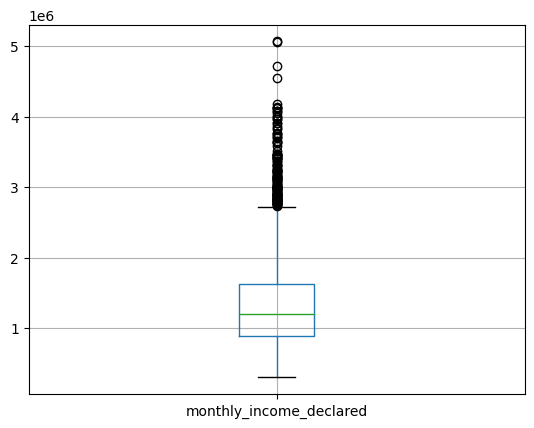

In [24]:
## ver como se encuentra la distribución de ingreso mensual declarado
predictoras.boxplot(column="monthly_income_declared")
plt.show()

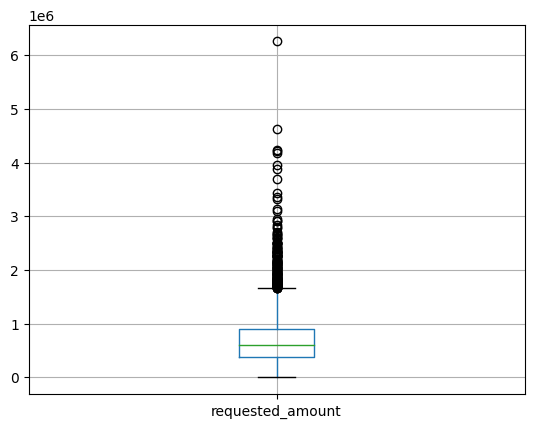

In [25]:
## ver como se encuentra la distribución de prestamo
predictoras.boxplot(column="requested_amount")
plt.show()

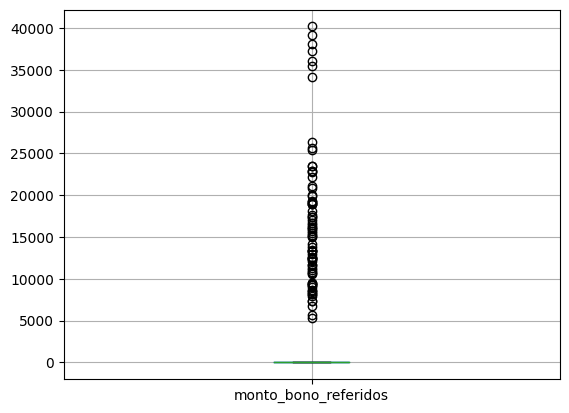

In [26]:
## ver como se encuentra la distribución de bonoreferidos
predictoras.boxplot(column="monto_bono_referidos")
plt.show()

## Union
se unira la Y calculada con las X

In [27]:
explicada=pd.read_csv('respuesta.csv',sep="|")
explicada

,application_id,fecha_apertura,cohorte,default
0,CAND-00001,2024-03-20,2024-03,0
1,CAND-00003,2024-01-21,2024-01,0
2,CAND-00005,2024-09-28,2024-09,0
3,CAND-00006,2024-10-18,2024-10,0
4,CAND-00007,2024-02-12,2024-02,0
...,...,...,...,...
3026,CAND-PH0117,2024-07-13,2024-07,0
3027,CAND-PH0118,2024-11-18,2024-11,0
3028,CAND-PH0119,2024-02-07,2024-02,0
3029,CAND-PH0121,2024-01-22,2024-01,0


In [28]:
### tasa de endeudamiento
predictoras["endeudamiento"]=round(predictoras["requested_amount"]/predictoras["monthly_income_declared"],2)
predictoras["tiene_bono"] = (predictoras["monto_bono_referidos"] > 0).astype(int)
predictoras["mes_solicitud"] = predictoras["application_date"].dt.to_period("M")
predictoras["bono_prestamo"]=round(predictoras["monto_bono_referidos"]/predictoras["requested_amount"],2)

In [29]:
base_final=pd.merge(explicada,predictoras,how="left",on="application_id")
base_final=base_final.dropna(subset=["application_date"])
base_final.shape

(2938, 26)

In [30]:
### se tiene una base de 2938 registros con una tasa de default del 8%
base_final['default'].value_counts()

0    2700
1     238
Name: default, dtype: int64

In [47]:
# %% 2. Variables explicativas: carga y limpieza
VENTANA, UMBRAL = 4, 90          
cart = pd.read_csv("cartera_variable_respuesta_candidato.csv")
cart["fecha_corte"] = pd.to_datetime(cart["fecha_corte"], format="%Y-%m-%d")
f1 = pd.to_datetime(cart["fecha_apertura"], format="%Y-%m-%d", errors="coerce")
f2 = pd.to_datetime(cart["fecha_apertura"], format="%d-%m-%Y", errors="coerce")
print("Fechas de apertura en formato DD-MM-YYYY corregidas:", int(f1.isna().sum()))
cart["fecha_apertura"] = f1.fillna(f2)
 
cart = cart.sort_values(["application_id", "fecha_corte"])
cart["n_corte"] = cart.groupby("application_id").cumcount() + 1

creditos = cart.groupby("application_id").agg(
    fecha_apertura=("fecha_apertura", "first"),
    n_cortes=("n_corte", "max"))
mora_ventana = cart[cart["n_corte"] <= VENTANA].groupby("application_id")["altura_mora"].max()
creditos["default"] = (mora_ventana >= UMBRAL).astype(int)

# Coherencia buró
inc1 = (~predictoras["has_bureau_record"] &predictoras["bureau_score"].notna()).sum()
inc2 = (predictoras["has_bureau_record"] & predictoras["bureau_score"].isna()).sum()
print(f"\nSin buró pero con score: {inc1} | Con buró pero sin score: {inc2}")
print("Faltantes por variable:")
print(predictoras.isna().sum()[predictoras.isna().sum() > 0])
 
# Cruce con cartera
ids_x, ids_c = set(predictoras["application_id"]), set(creditos.index)
huerfanos = sorted(ids_c - ids_x)
print(f"\nCréditos en cartera sin solicitud (se descartan): {len(huerfanos)}  ej: {huerfanos[:3]}")
print("Desembolsados sin registro en cartera:",
      (predictoras["disbursed_flag"] & ~predictoras["application_id"].isin(ids_c)).sum())
print("No desembolsados con registro en cartera:",
      (~predictoras["disbursed_flag"] & predictoras["application_id"].isin(ids_c)).sum())
 

Fechas de apertura en formato DD-MM-YYYY corregidas: 82

Sin buró pero con score: 0 | Con buró pero sin score: 0
Faltantes por variable:
monthly_income_declared          49
bureau_score                   2191
utility_payment_ontime_rate     255
telco_payment_ontime_rate       241
endeudamiento                    49
dtype: int64

Créditos en cartera sin solicitud (se descartan): 122  ej: ['CAND-PH0001', 'CAND-PH0002', 'CAND-PH0003']
Desembolsados sin registro en cartera: 0
No desembolsados con registro en cartera: 0


## EDA

In [31]:
base_final["endeudamiento"].value_counts().plot(kind="hist")

<AxesSubplot: ylabel='Frequency'>

In [32]:
base_final["bono_prestamo"].value_counts().plot(kind="hist")

<AxesSubplot: ylabel='Frequency'>

In [33]:
# Funciones de evaluación
def bins_cuantiles(s, n=5):
    q = np.unique(np.nanquantile(s.dropna(), np.linspace(0, 1, n + 1)))
    q[0], q[-1] = -np.inf, np.inf
    return q


def agrupar(s, cortes):
    """Asigna cada valor a su tramo; los faltantes van a un tramo propio."""
    if cortes is None:                         # variable categórica
        return s.astype(str).fillna("NA")
    return pd.cut(s, cortes).astype(str).where(s.notna(), "NA")


def tabla_woe(grupo, y):
    t = pd.crosstab(grupo, y)
    t.columns = ["buenos", "malos"]
    t["n"] = t["buenos"] + t["malos"]
    t["tasa_default"] = t["malos"] / t["n"]
    pb = (t["buenos"] + 0.5) / (t["buenos"].sum() + 0.5)
    pm = (t["malos"] + 0.5) / (t["malos"].sum() + 0.5)
    t["woe"] = np.log(pb / pm)
    t["iv"] = (pb - pm) * t["woe"]
    return t


def ks(y, score):
    fpr, tpr, _ = roc_curve(y, score)
    return np.max(tpr - fpr)


def psi(esperado, actual, n=10):
    esperado, actual = pd.Series(esperado).dropna(), pd.Series(actual).dropna()
    q = bins_cuantiles(esperado, n)
    pe = pd.cut(esperado, q).value_counts(normalize=True, sort=False).values
    pa = pd.cut(actual, q).value_counts(normalize=True, sort=False).values
    pe, pa = np.clip(pe, 1e-4, None), np.clip(pa, 1e-4, None)
    return float(np.sum((pa - pe) * np.log(pa / pe)))

In [34]:
base_final.columns

Index(['application_id', 'fecha_apertura', 'cohorte', 'default',
       'application_date', 'age', 'sexo', 'monthly_income_declared',
       'app_tenure_months', 'avg_monthly_topups', 'num_transactions_last_90d',
       'pct_p2p_transfers', 'device_price_tier', 'has_bureau_record',
       'bureau_score', 'utility_payment_ontime_rate',
       'telco_payment_ontime_rate', 'digital_engagement_score',
       'monto_bono_referidos', 'requested_amount', 'product_type',
       'disbursed_flag', 'endeudamiento', 'tiene_bono', 'mes_solicitud',
       'bono_prestamo'],
      dtype='object')

In [35]:
NUMERICAS = ["age", "app_tenure_months", "avg_monthly_topups",
             "num_transactions_last_90d", "pct_p2p_transfers", "device_price_tier",
             "bureau_score", "utility_payment_ontime_rate", "telco_payment_ontime_rate",
             "digital_engagement_score", "monto_bono_referidos", "requested_amount",
             "endeudamiento"]
CATEGORICAS = ["product_type", "has_bureau_record", "tiene_bono", "sexo"]

In [36]:
# %% 5. Análisis univariado: IV, AUC y KS por variable (muestra completa)
filas, tablas = [], {}
for v in NUMERICAS + CATEGORICAS:
    cortes = bins_cuantiles(base_final[v]) if v in NUMERICAS and base_final[v].nunique() > 5 else None
    t = tabla_woe(agrupar(base_final[v], cortes), base_final["default"])
    tablas[v] = t
    fila = {"variable": v, "IV": t["iv"].sum()}
    if v in NUMERICAS:
        z = base_final[[v, "default"]].dropna()
        a = roc_auc_score(z["default"], z[v])
        fila.update(AUC=max(a, 1 - a), KS=ks(z["default"], z[v] if a > 0.5 else -z[v]),
                    sentido="más alto = más riesgo" if a > 0.5 else "más alto = menos riesgo")
    filas.append(fila)
iv = pd.DataFrame(filas).sort_values("IV", ascending=False).round(3)
print(iv.to_string(index=False))

for v in ["avg_monthly_topups", "telco_payment_ontime_rate", "has_bureau_record", "bureau_score"]:
    print(f"\n{v}:")
    print(tablas[v][["n", "tasa_default", "woe"]].round(3))

                   variable    IV   AUC    KS                 sentido
         avg_monthly_topups 0.386 0.683 0.284 más alto = menos riesgo
               bureau_score 0.258 0.522 0.069   más alto = más riesgo
          has_bureau_record 0.227   NaN   NaN                     NaN
  telco_payment_ontime_rate 0.113 0.600 0.172 más alto = menos riesgo
utility_payment_ontime_rate 0.086 0.589 0.156 más alto = menos riesgo
           requested_amount 0.053 0.527 0.095 más alto = menos riesgo
   digital_engagement_score 0.043 0.518 0.092 más alto = menos riesgo
          pct_p2p_transfers 0.033 0.540 0.085   más alto = más riesgo
          app_tenure_months 0.018 0.510 0.046 más alto = menos riesgo
               product_type 0.017   NaN   NaN                     NaN
  num_transactions_last_90d 0.016 0.511 0.038 más alto = menos riesgo
              endeudamiento 0.009 0.505 0.027 más alto = menos riesgo
          device_price_tier 0.008 0.508 0.018   más alto = más riesgo
                    

In [55]:
# %% 6. Poblaciones diferentes
FECHA_OOT = "2024-10-01" 
print("a) Con y sin historial en buró:")
print(base_final.groupby("has_bureau_record")["default"].agg(["size", "mean"]).round(3))
print(pd.crosstab(base_final["has_bureau_record"], base_final["product_type"], values=base_final["default"],
                  aggfunc="mean").round(3))

print("\nb) Tasa de default por mes de solicitud:")
print(base_final.groupby("mes_solicitud")["default"].agg(["size", "mean"]).round(3).T)

print("\nc) Promedio mensual de las tasas de pago alternativas (TODAS las solicitudes):")
predictoras["mes"] = predictoras["application_date"].dt.to_period("M")
print(predictoras.groupby("mes")[["utility_payment_ontime_rate", "telco_payment_ontime_rate"]]
      .agg(["mean", "max"]).round(3))

antes, despues = predictoras[predictoras["application_date"] < FECHA_OOT], predictoras[predictoras["application_date"] >= FECHA_OOT]
print(f"\nPSI de cada variable: solicitudes antes vs desde {FECHA_OOT}")
psi_var = pd.Series({v: psi(antes[v], despues[v]) for v in NUMERICAS if v in predictoras})
print(psi_var.sort_values(ascending=False).round(3))

print("\nd) ¿La relación con el default se mantiene después del quiebre?")
base_final["periodo"] = np.where(base_final["application_date"] >= FECHA_OOT, "oct-dic", "ene-sep")
for v, cortes in [("utility_payment_ontime_rate", [0, .6, .7, .8, 1]),
                  ("telco_payment_ontime_rate", [0, .6, .7, .8, 1]),
                  ("avg_monthly_topups", [0, 2e4, 4e4, 7e4, 1e7])]:
    print(pd.crosstab(pd.cut(base_final[v], cortes), base_final["periodo"], values=base_final["default"],
                      aggfunc="mean").round(3))



a) Con y sin historial en buró:
                   size   mean
has_bureau_record             
False              1610  0.049
True               1328  0.120
product_type       avance_efectivo  compra_cartera  libre_inversion
has_bureau_record                                                  
False                        0.039           0.059            0.050
True                         0.109           0.146            0.115

b) Tasa de default por mes de solicitud:
mes_solicitud  2024-01  2024-02  2024-03  2024-04  2024-05  2024-06  2024-07  \
size           245.000  227.000  245.000  272.000  247.000  257.000  239.000   
mean             0.069    0.088    0.094    0.066    0.036    0.121    0.071   

mes_solicitud  2024-08  2024-09  2024-10  2024-11  2024-12  
size           251.000  217.000  247.000  260.000  231.000  
mean             0.084    0.046    0.097    0.073    0.126  

c) Promedio mensual de las tasas de pago alternativas (TODAS las solicitudes):
        utility_payment_on

In [59]:
# %% 7. Particiones: entrenamiento, prueba (mismo periodo) y fuera de tiempo
intime = base_final[base_final["application_date"] < FECHA_OOT]
oot = base_final[base_final["application_date"] >= FECHA_OOT]
train, test = train_test_split(intime, test_size=0.3, random_state=123,
                               stratify=intime["default"])
for n, d in [("train", train), ("test", test), ("oot", oot)]:
    print(f"{n:6s} n={len(d):5d}  defaults={d['default'].sum():4d}  tasa={d['default'].mean():.2%}")

train  n= 1540  defaults= 116  tasa=7.53%
test   n=  660  defaults=  50  tasa=7.58%
oot    n=  738  defaults=  72  tasa=9.76%


In [69]:
# %% 8. base_finalodelo: regresión logística sobre WoE (scorecard)

# Se excluye sexo (no discriminación) y se usa has_bureau_record en lugar de bureau_score.
# utility/telco quedan como candidatas; abajo se compara el modelo con y sin ellas.
CANDIDATAS = ["avg_monthly_topups", "telco_payment_ontime_rate", "utility_payment_ontime_rate",
              "has_bureau_record", "pct_p2p_transfers", "product_type", "requested_amount",
              "digital_engagement_score", "age"]


def ajustar_woe(train, variables):
    mapas = {}
    for v in variables:
        cortes = bins_cuantiles(train[v]) if v in NUMERICAS and train[v].nunique() > 5 else None
        t = tabla_woe(agrupar(train[v], cortes), train["default"])
        mapas[v] = (cortes, t["woe"])
    return mapas


def aplicar_woe(df, mapas):
    out = pd.DataFrame(index=df.index)
    for v, (cortes, woe) in mapas.items():
        out[v] = agrupar(df[v], cortes).map(woe).fillna(0)
    return out


def evaluar(variables, nombre, imprimir=True):
    mapas = ajustar_woe(train, variables)
    lr = LogisticRegression(C=1.0, max_iter=1000)
    lr.fit(aplicar_woe(train, mapas), train["default"])
    res, scores = {}, {}
    for n, d in [("train", train), ("test", test), ("oot", oot)]:
        p = lr.predict_proba(aplicar_woe(d, mapas))[:, 1]
        scores[n] = p
        res[n] = {"AUC": roc_auc_score(d["default"], p), "KS": ks(d["default"], p)}
    r = pd.DataFrame(res).T
    r["Gini"] = 2 * r["AUC"] - 1
    if imprimir:
        print(f"\n--- {nombre} ---")
        print(pd.Series(lr.coef_[0], index=variables).round(3).to_string())
        print(r.round(3))
    return lr, mapas, scores, r


# Selección por IV en train (IV >= 0.02)
iv_train = {v: tabla_woe(agrupar(train[v], bins_cuantiles(train[v]) if v in NUMERICAS
                                 and train[v].nunique() > 5 else None),
                         train["default"])["iv"].sum() for v in CANDIDATAS}
print("IV en train:", {k: round(v, 3) for k, v in sorted(iv_train.items(), key=lambda x: -x[1])})
seleccion = [v for v in CANDIDATAS if iv_train[v] >= 0.02]
print("Seleccionadas:", seleccion)

modelo_a = evaluar(seleccion, "Modelo A: todas las seleccionadas")
sin_utility = [v for v in seleccion if v != "utility_payment_ontime_rate"]
modelo_b = evaluar(sin_utility, "Modelo B: sin utility (variable con quiebre)")

# Referencia no lineal
num_gb = ["avg_monthly_topups", "telco_payment_ontime_rate", "utility_payment_ontime_rate",
          "pct_p2p_transfers", "requested_amount", "digital_engagement_score", "age",
          "monthly_income_declared", "app_tenure_months", "num_transactions_last_90d"]
def matriz_gb(d):
    z = d[num_gb].copy()
    z["has_bureau_record"] = d["has_bureau_record"].astype(int)
    z = z.join(pd.get_dummies(d["product_type"], prefix="prod").astype(int))
    return z
gb = HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=200,
                                    min_samples_leaf=40, random_state=123)
gb.fit(matriz_gb(train), train["default"])
print("\n--- Referencia: Gradient Boosting ---")
for n, d in [("train", train), ("test", test), ("oot", oot)]:
    p = gb.predict_proba(matriz_gb(d))[:, 1]
    print(f"{n:6s} AUC={roc_auc_score(d['default'], p):.3f}  KS={ks(d['default'], p):.3f}")

IV en train: {'avg_monthly_topups': 0.304, 'utility_payment_ontime_rate': 0.195, 'has_bureau_record': 0.172, 'pct_p2p_transfers': 0.077, 'telco_payment_ontime_rate': 0.061, 'requested_amount': 0.048, 'digital_engagement_score': 0.046, 'product_type': 0.042, 'age': 0.014}
Seleccionadas: ['avg_monthly_topups', 'telco_payment_ontime_rate', 'utility_payment_ontime_rate', 'has_bureau_record', 'pct_p2p_transfers', 'product_type', 'requested_amount', 'digital_engagement_score']

--- Modelo A: todas las seleccionadas ---
avg_monthly_topups            -0.989
telco_payment_ontime_rate     -0.998
utility_payment_ontime_rate   -1.034
has_bureau_record             -1.020
pct_p2p_transfers             -0.950
product_type                  -0.840
requested_amount              -0.942
digital_engagement_score      -0.817
         AUC     KS   Gini
train  0.772  0.440  0.544
test   0.723  0.399  0.446
oot    0.733  0.398  0.466

--- Modelo B: sin utility (variable con quiebre) ---
avg_monthly_topups     

In [68]:
# %% 8b. Validación robusta: validación cruzada, intervalo de confianza y calibración
# Con ~240 defaults, un solo split de prueba es muy ruidoso; se complementa con
# validación cruzada repetida (in-time) e intervalos bootstrap (OOT).
from sklearn.model_selection import RepeatedStratifiedKFold

intime_total = base_final[base_final["application_date"] < FECHA_OOT]
for nombre, variables in [("Modelo A", seleccion), ("Modelo B", sin_utility)]:
    aucs = []
    rkf = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=123)
    for i_tr, i_te in rkf.split(intime_total, intime_total["default"]):
        t, e = intime_total.iloc[i_tr], intime_total.iloc[i_te]
        mp = ajustar_woe(t, variables)
        m = LogisticRegression(max_iter=1000).fit(aplicar_woe(t, mp), t["default"])
        aucs.append(roc_auc_score(e["default"], m.predict_proba(aplicar_woe(e, mp))[:, 1]))

    lr, mapas, scores, _ = evaluar(variables, nombre, imprimir=False)
    p, y = scores["oot"], oot["default"].values
    rng = np.random.default_rng(123)
    boot = []
    for _ in range(1000):
        i = rng.integers(0, len(y), len(y))
        boot.append(roc_auc_score(y[i], p[i]))
    print(f"{nombre}: AUC CV in-time = {np.mean(aucs):.3f} ± {np.std(aucs):.3f} | "
          f"AUC OOT = {roc_auc_score(y, p):.3f} (IC95 {np.percentile(boot, 2.5):.3f}-"
          f"{np.percentile(boot, 97.5):.3f}) | PD media OOT = {p.mean():.3f} vs real = {y.mean():.3f}")


Modelo A: AUC CV in-time = 0.723 ± 0.034 | AUC OOT = 0.733 (IC95 0.670-0.799) | PD media OOT = 0.084 vs real = 0.098
Modelo B: AUC CV in-time = 0.706 ± 0.044 | AUC OOT = 0.747 (IC95 0.688-0.808) | PD media OOT = 0.077 vs real = 0.098


In [71]:
# %% 9. PSI del score entre particiones
for nombre, (lr, mapas, scores, r) in [("Modelo A", modelo_a), ("Modelo B", modelo_b)]:
    print(f"{nombre}: PSI train vs test = {psi(scores['train'], scores['test']):.3f} | "
          f"PSI train vs oot = {psi(scores['train'], scores['oot']):.3f}")

print("\nPSI de las variables del modelo (train vs oot):")
print(pd.Series({v: psi(train[v].astype(float), oot[v].astype(float))
                 for v in seleccion if v in NUMERICAS}).round(3))

Modelo A: PSI train vs test = 0.016 | PSI train vs oot = 0.029
Modelo B: PSI train vs test = 0.025 | PSI train vs oot = 0.013

PSI de las variables del modelo (train vs oot):
avg_monthly_topups             0.017
telco_payment_ontime_rate      0.093
utility_payment_ontime_rate    0.107
pct_p2p_transfers              0.017
requested_amount               0.003
digital_engagement_score       0.016
dtype: float64


In [74]:
# %% 10. Tabla de desempeño por deciles (modelo B en OOT)

_, _, scores_b, _ = modelo_b
d = oot[["default"]].copy()
d["pd"] = scores_b["oot"]
d["decil"] = pd.qcut(d["pd"].rank(method="first"), 10, labels=range(1, 11))
print(d.groupby("decil", observed=True).agg(n=("default", "size"), pd_media=("pd", "mean"),
                                            tasa_real=("default", "mean")).round(3))


        n  pd_media  tasa_real
decil                         
1      74     0.015      0.027
2      74     0.026      0.027
3      74     0.034      0.027
4      73     0.043      0.014
5      74     0.054      0.108
6      74     0.067      0.054
7      73     0.082      0.123
8      74     0.103      0.054
9      74     0.137      0.230
10     74     0.213      0.311


In [73]:
# %% 11. Auditoría de equidad (sexo NO entra al modelo; se usa solo para revisar)
todo = pd.concat([test, oot])
todo["pd"] = np.r_[scores_b["test"], scores_b["oot"]]
print(todo.groupby("sexo").agg(n=("pd", "size"), pd_media=("pd", "mean"),
                               tasa_real=("default", "mean")).round(3))

        n  pd_media  tasa_real
sexo                          
H     713     0.076      0.084
M     633     0.080      0.090
NB     52     0.068      0.096
